In [88]:
import cga_utils
import prompt_versions
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [89]:
from langchain.globals import set_llm_cache
from langchain_community.cache import SQLiteCache

set_llm_cache(SQLiteCache(database_path=".langchain.ollama38.db"))

In [90]:
from langchain_community.chat_models import ChatOllama
llm = ChatOllama(model="qwen3:4b", temperature = 0.0, top_p = 1, repeat_penalty=1, presence_penalty=0, frequency_penalty=0)  # vagy bármely más elérhető Ollama modell

In [94]:
import pandas as pd
messages = prompt_versions.prompt_versions['V19']
messages = [(a, t.replace('/no_think','')) for (a,t)  in messages]
messages[-1] = ( messages[-1][0],  messages[-1][1] + "/no_think" ) 



#problematic_qids = list(pd.read_csv('res/e37.csv').query('error_code == "selection_error" and calc_pattern == "(#+#)/#"')['qid'])
#df = pd.read_csv('res/e38_19.csv')
#problematic_qids = list(df[df["question"].str.contains("percentage change")]['qid'])

#res = cga_utils.execute_datset_predictions(llm, messages, problematic_qids)
res = cga_utils.execute_datset_predictions(llm, messages)

0it [00:00, ?it/s]

b2786c1a-37de-4120-b03c-32bf5c81f157
What was the change in the amount for Appliances in 2019 from 2018? Success: -94.0
<< 680-774 || [680.0, 774.0, -94.0] || [680.0, 774.0] || True >>
fe11f001-3bfe-4089-8108-412676f0a780
What was the percentage change in the amount for Appliances in 2019 from 2018? Success: -12.14
<< (680-774)/774 || [680.0, 774.0, -12.144702842377262] || [680.0, 774.0, 774.0] || True >>
5103aed0-b4e8-4fae-bf78-e2c9f4ba84cf
What is the difference between the domestic and international discount rates as at September 30, 2019? Success: 2.1
<< 4.00 - 1.90  || [4.0, 1.9] || [4.0, 1.9] || True >>
4dc8be43-d8d9-4b08-9ffd-9c19012361ce
What is the year on year percentage change in domestic discount rate between 2018 and 2019? Success: 6.67
<< (4.00 - 3.75)/3.75  || [3.75, 4.0, 6.666666666666667] || [4.0, 3.75, 3.75] || True >>
6c44a1a8-0785-43a0-90ab-7e21df2c57d9
What is the year on year percentage change in international expected return on plan assets between 2018 and 2019? 

In [95]:
annotated_results = cga_utils.annotate_results(res)
#annotated_results.to_csv('res/Ollama_2_gemma3n_e4b_code_values_v11_m1.csv')
cga_utils.calc_overall_value_match(annotated_results)

0.7364185110663984

In [96]:

cga_utils.calc_overall_em(annotated_results), cga_utils.calc_overall_em_alt(annotated_results)

(0.6237424547283702, 0.6237424547283702)

In [52]:
_, m = cga_utils.calc_overall_em_metrics(res)
[i for i in m._details if i['answer'] == 0]

[{'answer_type': 'arithmetic',
  'answer': 0,
  'scale': 'percent',
  'pred': [0.0],
  'pred_scale': 'percent',
  'em': 1.0,
  'f1': 1.0,
  'pred_span': None,
  'gold_span': None,
  'span_em': 0,
  'span_f1': 0},
 {'answer_type': 'arithmetic',
  'answer': 0,
  'scale': 'percent',
  'pred': [0.0],
  'pred_scale': 'percent',
  'em': 1.0,
  'f1': 1.0,
  'pred_span': None,
  'gold_span': None,
  'span_em': 0,
  'span_f1': 0},
 {'answer_type': 'arithmetic',
  'answer': 0,
  'scale': 'percent',
  'pred': [-0.0],
  'pred_scale': 'percent',
  'em': 0.0,
  'f1': 0.0,
  'pred_span': None,
  'gold_span': None,
  'span_em': 0,
  'span_f1': 0},
 {'answer_type': 'arithmetic',
  'answer': 0,
  'scale': 'percent',
  'pred': [0.0],
  'pred_scale': '',
  'em': 1.0,
  'f1': 1.0,
  'pred_span': None,
  'gold_span': None,
  'span_em': 0,
  'span_f1': 0}]

In [68]:
annotated_results.to_csv('res/e38_19.csv')

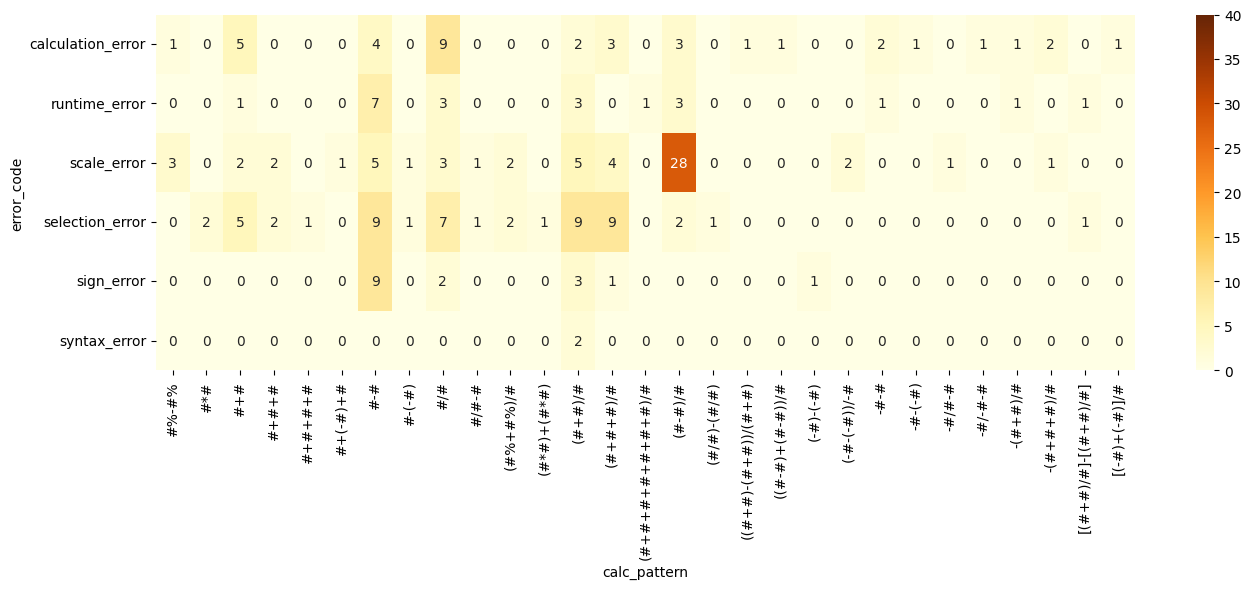

190

In [45]:
df = annotated_results.query('error_code != "none"')
cga_utils.crosstab_heatmap(df, 'error_code', 'calc_pattern', 40)
len(df)

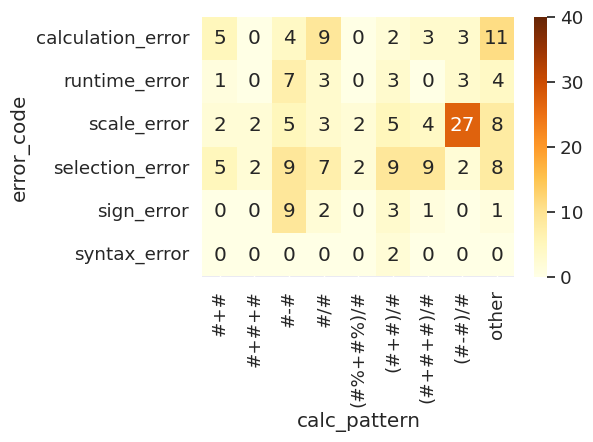

187

In [87]:
df = annotated_results.query('error_code != "none"')
cga_utils.crosstab_heatmap(df, 'error_code', 'calc_pattern', 40, 0, 3)
len(df)

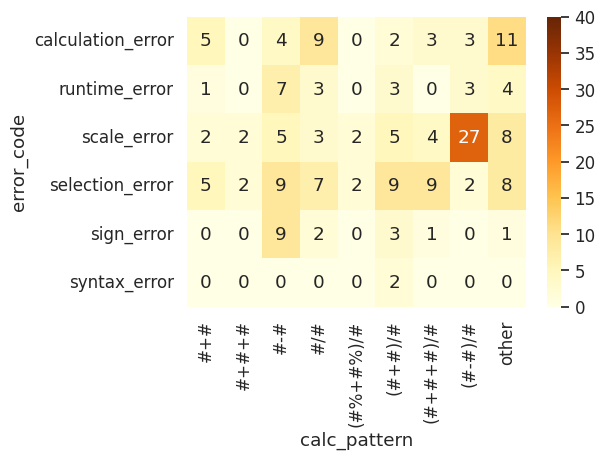

187

In [85]:
df = annotated_results.query('error_code != "none"')
cga_utils.crosstab_heatmap(df, 'error_code', 'calc_pattern', 40, 0, 3)
len(df)

Series([], Name: exact_match, dtype: float64)


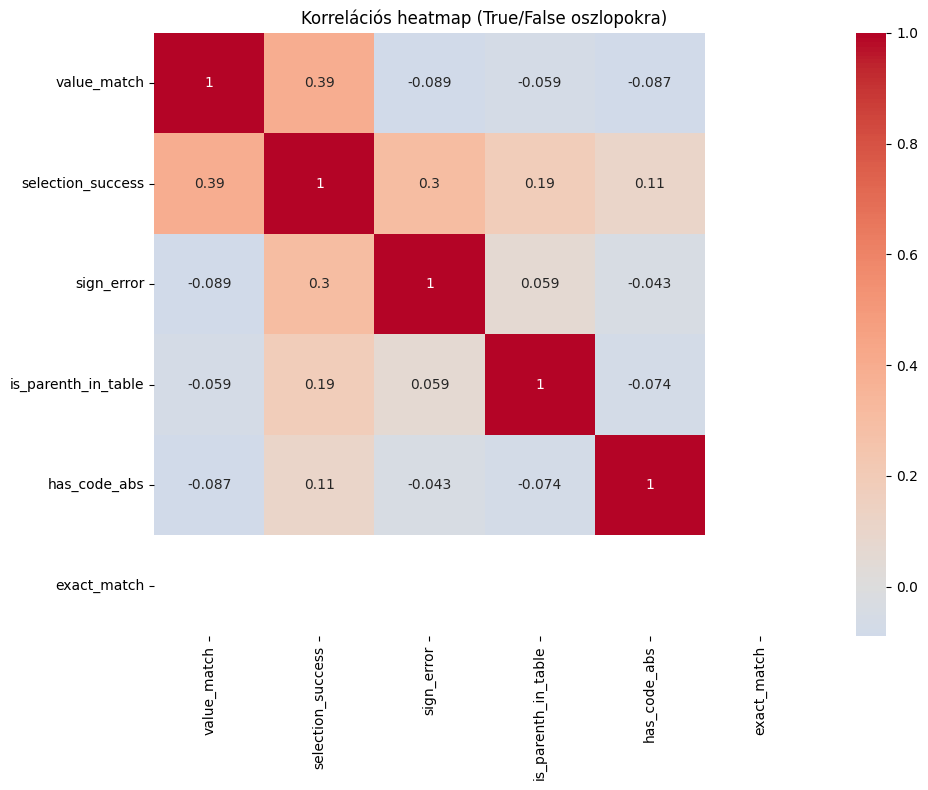

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = annotated_results.query('error_code != "none"')

# 1. Csak a True/False típusú oszlopokat szűrjük ki
bool_cols = df.select_dtypes(include=['bool'])

# 2. Korrelációs mátrix számítása
corr = bool_cols.corr()
em_corr = bool_cols.corr()['exact_match'].dropna().sort_values(ascending=False)

print(em_corr)

# 3. Heatmap megjelenítés
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

plt.title("Korrelációs heatmap (True/False oszlopokra)")
plt.tight_layout()
plt.show()


In [42]:
bool_cols

,value_match,selection_success,sign_error,is_parenth_in_table,has_code_abs,exact_match
6,False,False,False,False,False,False
8,False,False,False,True,False,False
16,False,False,False,True,False,False
17,False,True,False,True,False,False
22,False,False,False,True,False,False
...,...,...,...,...,...,...
482,False,False,False,True,False,False
484,True,True,False,False,False,False
489,False,True,False,True,False,False
490,False,True,True,True,False,False
